In [1]:
#ultralytics 라이브러리를 설치합니다.
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.5 MB/s eta 0:00:00


In [2]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


문제 1 (단답형 주관식)

Two-Stage Detector (예: Faster R-CNN)와 One-Stage Detector (예: YOLO)의 가장 큰 아키텍처 차이점(처리 방식)을 1~2줄로 간략히 서술하시오.


2 stage detector는 Region Proposal(영역 제안)을 거쳐 분류 및 회귀가 이루어지는 반면, 1 stage detector는 단일 신경망이 이미지 전체를 한번만 보며 위치와 클래스를 동시에 예측한다.

문제 2 (단답형 주관식)

YOLO (You Only Look Once) 모델은 이미지를 S x S 그리드(grid)로 나눕니다. 이 그리드 셀(grid cell)이 예측해야 하는 3가지 주요 정보(YOLO 손실 함수를 구성하는 3요소)가 무엇인지 서술하시오.

2번 답을 적어주세요.
- 1) BBox의 좌표(x,y,w,h)
- 2) Confidence score(객체 존재 여부의 신뢰성)
- 3) 객체가 존재할 경우, 해당 객체가 특정 클래스에 속할 확률

문제 3 (실습 문제 - 코드 빈칸 채우기)

ultralytics 라이브러리를 사용하여, ImageNet에서 사전 학습된 YOLOv8 nano 모델(yolov8n.pt)을 로드하는 코드입니다.

2개의 빈칸 (# TODO: ...)을 채워 라이브러리를 임포트하고 모델을 로드하시오.

In [3]:
from ultralytics import YOLO

# TODO: 1. 'yolov8n.pt' 사전 학습 모델을 로드
model = YOLO('yolov8n.pt')

# --- 결과 확인 (수정 불필요) ---
print(model.names) # 로드된 모델의 클래스 이름들 출력

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

문제 4 (실습 문제 - 코드 빈칸 채우기)

문제 3에서 로드한 model을 사용하여, IMAGE_URL에 있는 이미지에 대해 confidence threshold를 0.4로 설정하여 객체 검출을 수행(predict)하는 코드입니다.

2개의 빈칸 (# TODO: ...)을 채우시오.


image 1/1 /content/bus.jpg: 640x480 3 persons, 1 bus, 356.0ms
Speed: 14.2ms preprocess, 356.0ms inference, 36.9ms postprocess per image at shape (1, 3, 640, 480)
검출된 객체 수: 4


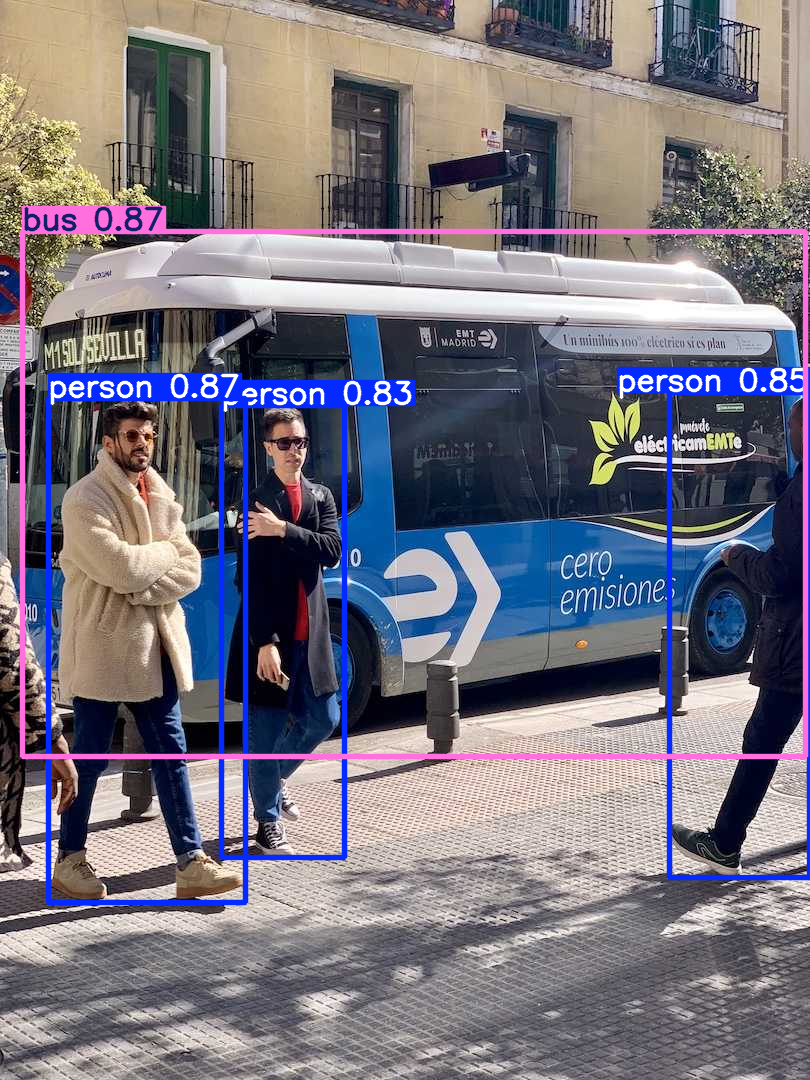

In [5]:
# --- 이미지 URL (수정 불필요) ---
IMAGE_URL = 'https://ultralytics.com/images/bus.jpg'
# ---------------------------------

# (문제 3의 model 변수를 사용)

# TODO: 1. model.predict() 함수를 사용하여 추론 수행
results = model.predict(
    source = IMAGE_URL,  # TODO: 2. source 인자에 URL 지정
    conf = 0.4     # TODO: 3. conf 인자에 0.4 지정
)

# --- 결과 확인 (수정 불필요) ---
print(f"검출된 객체 수: {len(results[0].boxes)}")
results[0].show() # 결과 시각화

문제 5 (실습 문제 - 코드 빈칸 채우기)

model.predict()의 반환값인 results에서, 검출된 객체들의 바운딩 박스(boxes) 정보를 순회(loop)하며, 클래스 이름(name)과 신뢰도(conf)를 출력하는 코드입니다.

4개의 빈칸 (# TODO: ...)을 채우시오.

In [9]:
# (문제 4의 results 변수를 사용)

print("--- 검출된 객체 상세 정보 ---")

# TODO: 1. 첫 번째 결과(results[0])의 바운딩 박스 리스트(.boxes) 순회
for box in results[0].boxes:

    # TODO: 2. box 객체에서 클래스 인덱스(.cls) 추출 (스칼라 값으로)
    cls_id = int(box.cls[0].cpu().item())

    # TODO: 3. 모델의 클래스 이름 리스트(model.names)에서 cls_id로 'class_name' 조회
    class_name = model.names[cls_id]

    # TODO: 4. box 객체에서 신뢰도(.conf) 추출 (스칼라 값으로)
    conf = float(box.conf[0].cpu().item())

    print(f"  - 클래스: {class_name}, 신뢰도: {conf:.3f}")


# --- 결과 확인 (수정 불필요) ---
print("\n(참고) 전체 model.names 딕셔너리:")
print(model.names)

--- 검출된 객체 상세 정보 ---
  - 클래스: bus, 신뢰도: 0.873
  - 클래스: person, 신뢰도: 0.866
  - 클래스: person, 신뢰도: 0.853
  - 클래스: person, 신뢰도: 0.825

(참고) 전체 model.names 딕셔너리:
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 

문제 6 (실습 문제 - 코드 작성)

YOLOv8 모델을 사용하여 IMAGE_URL_1과 IMAGE_URL_2 두 개의 이미지를 배치(batch)로 한 번에 추론하는 코드입니다.

model.predict()를 한 번만 호출하여 batch_results를 생성하시오. [Source: (ipynb, cell 18)]

[요구사항]

- 입력 source는 두 개의 URL 리스트여야 합니다.
- 신뢰도(conf)는 0.5로 설정합니다.
- 결과 이미지(save=True)를 저장하도록 설정합니다.

In [10]:
# --- 이미지 URL (수정 불필요) ---
IMAGE_URL_1 = 'https://ultralytics.com/images/bus.jpg'
IMAGE_URL_2 = 'https://ultralytics.com/images/zidane.jpg'
# ---------------------------------

# (문제 3의 model 변수를 사용)

# TODO: 1. 두 개 이미지를 리스트로 묶어 배치 추론 수행
batch_results = model.predict(
    source=[IMAGE_URL_1, IMAGE_URL_2],
    conf=0.5,
    save=True
)

# --- 결과 확인 (수정 불필요) ---
print(f"처리된 이미지 개수: {len(batch_results)}")

print("\n--- 첫 번째 이미지 결과 ---")
batch_results[0].show()

print("\n--- 두 번째 이미지 결과 ---")
batch_results[1].show()

Output hidden; open in https://colab.research.google.com to view.

[자율학습]